Give a basic python implementation of the gradient decent  that starts with an arbitrary point, start, iteratively moves it toward the minimum, and returns a point that is at or near the minimum


Below is pesudo code for the gradient descent algorithm:

**Input:**
- **Function \( J(\theta) \):** The cost function to minimize.
- **Gradient \( \nabla J(\theta) \):** The gradient of the cost function.
- **Learning rate \( \alpha \):** Step size.
- **Tolerance \( \epsilon \):** Convergence threshold.
- **Maximum iterations \( N \):** (Optional) Maximum iterations to avoid infinite loops.

**Output:**
- **Optimized parameters \( \theta \)**

**Procedure:**
1. **Initialize** \( \theta \) (e.g., randomly or with zeros).
2. **Set** iteration count \( k = 0 \).
3. **Repeat:**
   - **a.** Compute gradient: \( \text{grad} = \nabla J(\theta) \).
   - **b.** If \( \|\text{grad}\| < \epsilon \) or \( k \geq N \), then break.
   - **c.** Update parameters: \( \theta = \theta - \alpha \times \text{grad} \).
   - **d.** Increment iteration count: \( k = k + 1 \).
4. **Return** \( \theta \).


## Question 1: 
Test your algorithm with a function  y=x2. Use a learning rate of 0.2, 0.8.  Start at point 10. Plot the steps and explain the difference between these learning rates. 

Convergence reached at iteration 33
Convergence reached at iteration 33


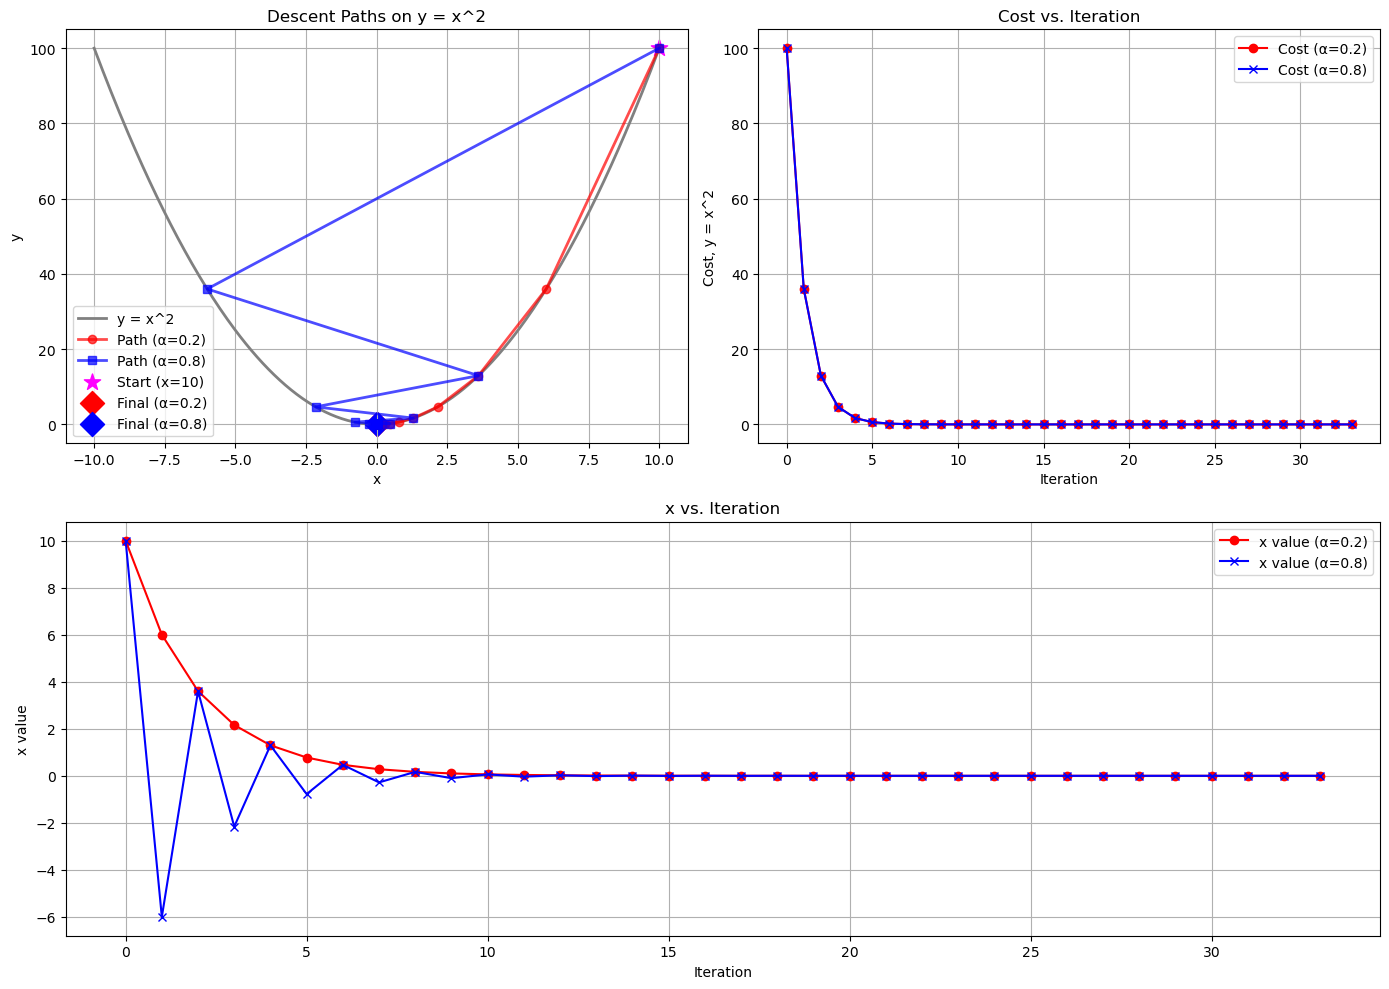

In [212]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**2

def grad_func(x):
    return 2 * x

def gradient_descent(start, learning_rate, tolerance=1e-6, max_iter=50):
    x = start
    x_values = [x]
    cost_values = [f(x)]
    for i in range(max_iter):
        grad = grad_func(x)
        if np.abs(grad) < tolerance:
            print(f"Convergence reached at iteration {i}")
            break
        x = x - learning_rate * grad
        x_values.append(x)
        cost_values.append(f(x))
    return x_values, cost_values

start_point = 10
max_iter = 50
learning_rate_1 = 0.2
learning_rate_2 = 0.8

x_vals_1, cost_vals_1 = gradient_descent(start_point, learning_rate=learning_rate_1, max_iter=max_iter)
x_vals_2, cost_vals_2 = gradient_descent(start_point, learning_rate=learning_rate_2, max_iter=max_iter)

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
x_range = np.linspace(-10, 10, 400)
plt.plot(x_range, f(x_range), label="y = x^2", linewidth=2, color='gray')
plt.plot(x_vals_1, [f(x) for x in x_vals_1], color='red', marker='o', label="Path (α=0.2)", linewidth=2, alpha=0.7)
plt.plot(x_vals_2, [f(x) for x in x_vals_2], color='blue', marker='s', label="Path (α=0.8)", linewidth=2, alpha=0.7)
plt.scatter([start_point], [f(start_point)], color='magenta', s=150, marker='*', label="Start (x=10)")
plt.scatter(x_vals_1[-1], f(x_vals_1[-1]), color='red', s=150, marker='D', label="Final (α=0.2)")
plt.scatter(x_vals_2[-1], f(x_vals_2[-1]), color='blue', s=150, marker='D', label="Final (α=0.8)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Descent Paths on y = x^2")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(range(len(cost_vals_1)), cost_vals_1, marker='o', color='red', label="Cost (α=0.2)")
plt.plot(range(len(cost_vals_2)), cost_vals_2, marker='x', color='blue', label="Cost (α=0.8)")
plt.xlabel("Iteration")
plt.ylabel("Cost, y = x^2")
plt.title("Cost vs. Iteration")
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(range(len(x_vals_1)), x_vals_1, marker='o', color='red', label="x value (α=0.2)")
plt.plot(range(len(x_vals_2)), x_vals_2, marker='x', color='blue', label="x value (α=0.8)")
plt.xlabel("Iteration")
plt.ylabel("x value")
plt.title("x vs. Iteration")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


#### Explanation of Gradient Descent on \( y = x^2 \)

Below is a concise explanation of the behavior you see in the three subplots (Descent Path, Cost vs. Iteration, and \( x \) vs. Iteration) when using learning rates \( \alpha = 0.2 \) and \( \alpha = 0.8 \) starting at \( x = 10 \) for the function

\[
y = x^2.
\]

---

#### 1. Descent Path on \( y = x^2 \) (Left Plot)

- **Learning Rate \(\alpha = 0.2\) (Red)**  
  - The steps are moderate, so the path moves smoothly down the parabola from \( x = 10 \) toward \( x = 0 \).  
  - Each iteration reduces \( x \) closer to zero without flipping signs or oscillating.

- **Learning Rate \(\alpha = 0.8\) (Blue)**  
  - The steps are larger. After the first update, the algorithm overshoots the minimum, crossing into negative \( x \).  
  - Subsequent steps keep overshooting around \( x = 0 \), resulting in a zigzag (oscillation) on the parabola, but still gradually reducing \(\lvert x \rvert\).

This difference illustrates how a **larger learning rate** can cause **instability** and **oscillations**, whereas a **smaller rate** produces a **more stable, monotonic** descent.

---

#### 2. \( x \) vs. Iteration (Bottom Plot)

- **\(\alpha = 0.2\) (Red)**  
  - \( x \) decreases smoothly from 10 toward 0, mostly monotonic—no sign changes or big swings.

- **\(\alpha = 0.8\) (Blue)**  
  - \( x \) crosses from positive to negative multiple times. These overshoots occur because the update step \( \alpha \cdot 2x \) is relatively large.  
  - The magnitude of \( x \) shrinks over iterations, but the sign flips until the steps become small enough to settle near zero.

---

So, in summary:

1. **Step Size Effect**  
   - **Smaller \(\alpha = 0.2\)**: Safer, more controlled steps, converging in a stable fashion without oscillations.  
   - **Larger \(\alpha = 0.8\)**: Bigger jumps around the minimum, leading to overshoot and sign-flipping oscillations.

2. **Convergence**  
   - Both learning rates eventually converge to \( x \approx 0 \).  
   - The cost function \( y = x^2 \) only depends on \(\lvert x \rvert\), so even if the sign of \( x \) flips, the cost can still decrease.

The thing that we can take away from this is that:
   - A **large learning rate** can make gradient descent unstable, causing oscillations or even divergence.  
   - A **moderate or smaller learning rate** yields more stable convergence, though it can be slower in some cases.


## Question 2: 

Use the same function in the previous point  y=x2 , Use a learning rate 0.005, use a number of maximum iterations. Report the MLE using 100,1000 and 2000 iterations. Explain the difference between this rate and the rates in part 1. Explain the difference with the different maximum number of iterations. 

After 100 iterations: x = 3.660323412732294, cost = 13.397967485796189
After 1000 iterations: x = 0.0004317124741065828, cost = 1.8637566029922695e-07
After 2000 iterations: x = 1.863756602992269e-08, cost = 3.4735886751972827e-16


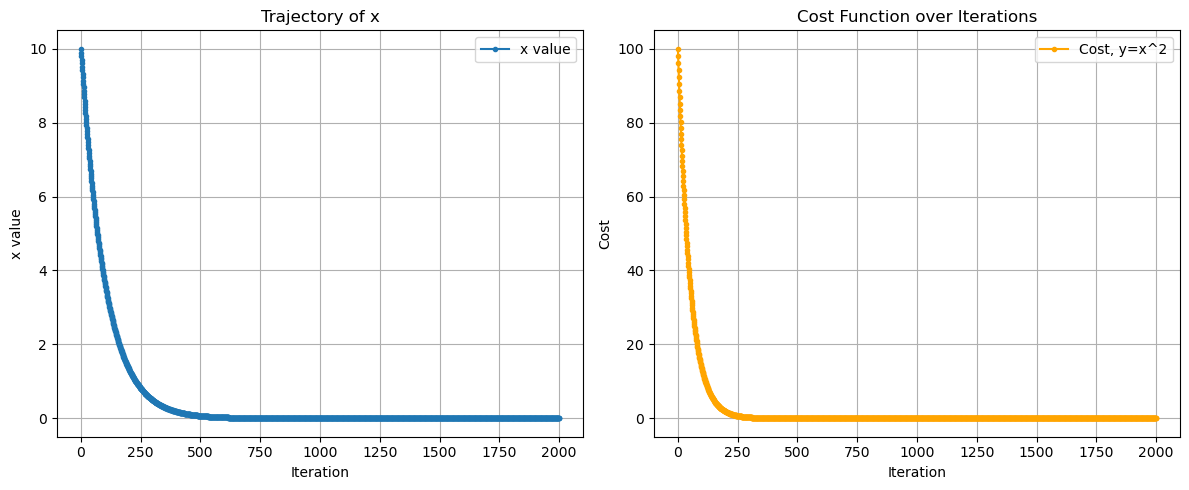

In [211]:
import numpy as np
import matplotlib.pyplot as plt

def cost_func(x):
    return x**2

def grad_func(x):
    return 2 * x

def gradient_descent_full(start, learning_rate, max_iter):
    x = start
    x_values = [x]
    for i in range(max_iter):
        x = x - learning_rate * grad_func(x)
        x_values.append(x)
    return x_values

start_point = 10
learning_rate = 0.005
max_iter = 2000
x_values = gradient_descent_full(start_point, learning_rate, max_iter)

iters_to_report = [100, 1000, 2000]
for it in iters_to_report:
    x_est = x_values[it]
    cost_est = cost_func(x_est)
    print(f"After {it} iterations: x = {x_est}, cost = {cost_est}")

iterations = range(max_iter+1)
cost_values = [cost_func(x) for x in x_values]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(iterations, x_values, marker='.', label='x value')
plt.xlabel('Iteration')
plt.ylabel('x value')
plt.title('Trajectory of x')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(iterations, cost_values, marker='.', color='orange', label='Cost, y=x^2')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost Function over Iterations')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


#### Impact of Learning Rate on Gradient Descent Convergence

For the function 

\[
f(x) = x^2,
\]

the global minimum is at \( x = 0 \). In this context, if we interpret \( f(x) \) as a negative log-likelihood function (up to a constant), then the maximum likelihood estimate (MLE) corresponds to the value of \( x \) that minimizes \( f(x) \)—which is \( x = 0 \).

When using a **smaller learning rate** (e.g., 0.005), each update step is much smaller than with larger rates. This causes the algorithm to progress toward the minimum very slowly. Although this slower pace reduces the risk of overshooting the minimum, it also requires significantly more iterations to converge.

In **Task 1**, we observed:
- With a learning rate of **0.2**, the algorithm moved quickly and steadily toward the minimum.
- With a learning rate of **0.8**, the algorithm initially made faster progress but risked overshooting and oscillating around the minimum.

In contrast, with a learning rate of **0.005**:
- The descent is very smooth and steady.
- After just **100 iterations**, the final \( x \) value was still around 3.66, which is far from the true minimum (MLE) at \( x = 0 \).
- However, by increasing the iterations to **1000** and then **2000**, the algorithm gradually approached the true minimum (MLE) at \( x = 0 \).

This illustrates a key trade-off in gradient descent:
- **Smaller learning rates** lead to safer and more precise convergence but require more computational time and iterations.
- **Larger learning rates** can accelerate convergence but risk instability, overshooting, and oscillations.

Selecting an appropriate **learning rate** and **number of iterations** is crucial for balancing convergence speed and stability, especially when aiming to accurately estimate the MLE (in this case, \( x = 0 \) for \( f(x) = x^2 \)).


# Question 3
 Test you algorithm with the function y= x4-5x2-3x. Report the local and global minimum.   Use learning rate 0.2, 0.1. Start at point zero. Plot the steps and explain the difference between the learning rates. 

Learning rate 0.2: Final x = -1.1341, f(x) = -1.3744
Learning rate 0.1: Final x = 1.0393, f(x) = -7.3522


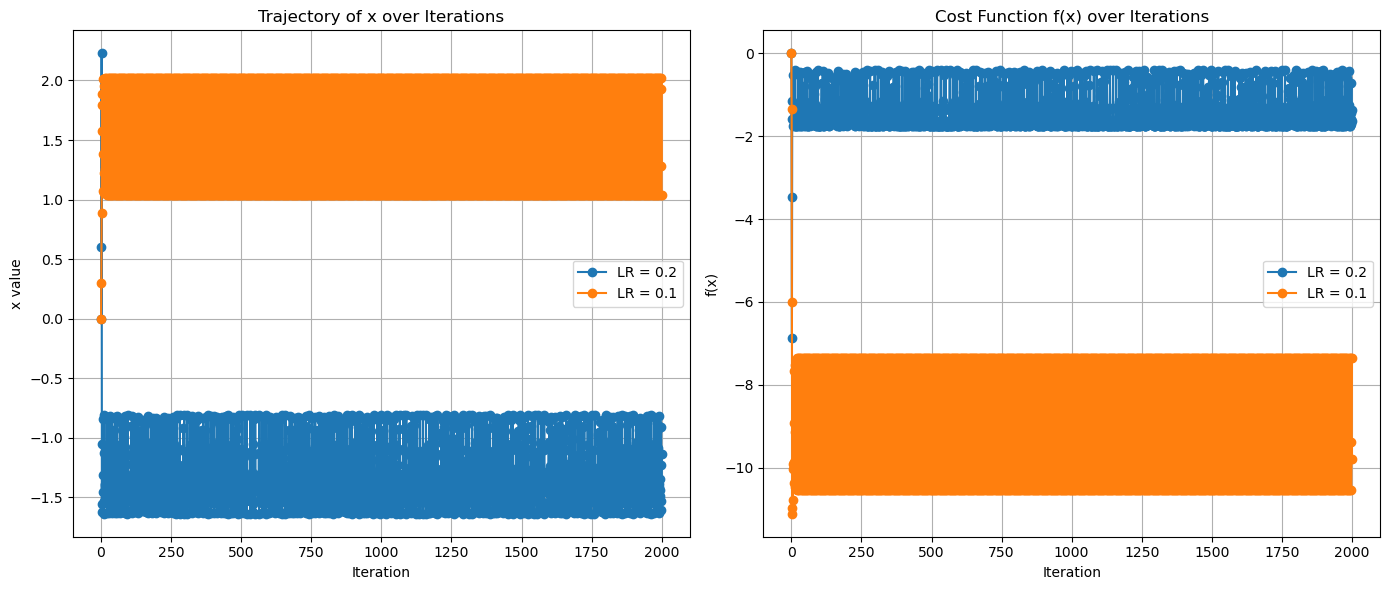

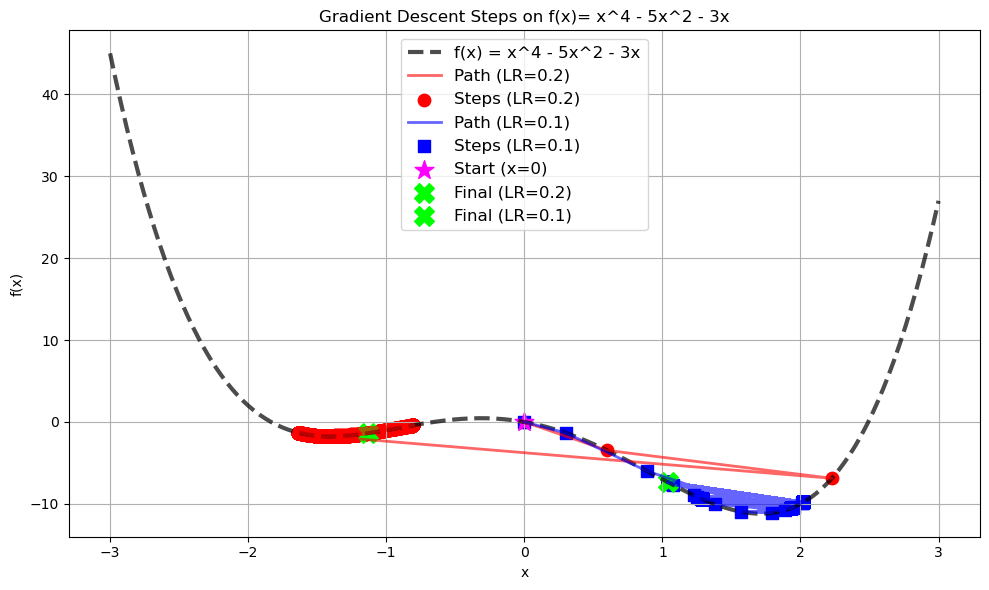

In [210]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    """Cost function: f(x)= x^4 - 5x^2 - 3x"""
    return x**4 - 5*x**2 - 3*x

def grad(x):
    """Gradient: f'(x)= 4x^3 - 10x - 3"""
    return 4*x**3 - 10*x - 3

def gradient_descent(start, lr, max_iter):
    """
    Runs gradient descent starting from a given point.
    
    Parameters:
        start (float): Initial x value.
        lr (float): Learning rate.
        max_iter (int): Number of iterations.
    
    Returns:
        xs (list): x values at each iteration.
    """
    xs = [start]
    x = start
    for i in range(max_iter):
        x = x - lr * grad(x)
        xs.append(x)
    return xs

start = 0
max_iter = 2000
learning_rates = [0.2, 0.1]

results = {}
for lr in learning_rates:
    xs = gradient_descent(start, lr, max_iter)
    results[lr] = xs

final_results = {}
for lr, xs in results.items():
    final_x = xs[-1]
    final_cost = f(final_x)
    final_results[lr] = (final_x, final_cost)
    print(f"Learning rate {lr}: Final x = {final_x:.4f}, f(x) = {final_cost:.4f}")

iterations = range(max_iter + 1)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
for lr in learning_rates:
    plt.plot(iterations, results[lr], marker='o', label=f'LR = {lr}')
plt.xlabel("Iteration")
plt.ylabel("x value")
plt.title("Trajectory of x over Iterations")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for lr in learning_rates:
    costs = [f(x) for x in results[lr]]
    plt.plot(iterations, costs, marker='o', label=f'LR = {lr}')
plt.xlabel("Iteration")
plt.ylabel("f(x)")
plt.title("Cost Function f(x) over Iterations")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

x_range = np.linspace(-3, 3, 300)
plt.plot(x_range, f(x_range), label="f(x) = x^4 - 5x^2 - 3x", color='black', 
         linewidth=3, linestyle='--', alpha=0.7)

plt.plot(results[0.2], [f(x) for x in results[0.2]], color='red', linewidth=2, alpha=0.6, label='Path (LR=0.2)')
plt.scatter(results[0.2], [f(x) for x in results[0.2]], color='red', marker='o', s=80, label='Steps (LR=0.2)')

plt.plot(results[0.1], [f(x) for x in results[0.1]], color='blue', linewidth=2, alpha=0.6, label='Path (LR=0.1)')
plt.scatter(results[0.1], [f(x) for x in results[0.1]], color='blue', marker='s', s=80, label='Steps (LR=0.1)')

plt.scatter(start, f(start), color='magenta', marker='*', s=200, label='Start (x=0)')

plt.scatter(results[0.2][-1], f(results[0.2][-1]), color='lime', marker='X', s=200, label='Final (LR=0.2)')
plt.scatter(results[0.1][-1], f(results[0.1][-1]), color='lime', marker='X', s=200, label='Final (LR=0.1)')

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Gradient Descent Steps on f(x)= x^4 - 5x^2 - 3x")
plt.legend(loc='upper center', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


#### Explanation of Gradient Descent Results on \( y = x^4 - 5x^2 - 3x \)

In our experiment, we applied gradient descent to the function

\[
y = x^4 - 5x^2 - 3x,
\]

which is a non-convex polynomial with multiple critical points. We tested two different learning rates, both starting from \( x = 0 \):

- **For \( \alpha = 0.2 \):**  
  - **Final \( x \) = -1.1341**  
  - **Final \( y \) = -1.3744**

- **For \( \alpha = 0.1 \):**  
  - **Final \( x \) = 1.0393**  
  - **Final \( y \) = -7.3522**

---

#### Critical Points of the Function

The derivative of the function is

\[
f'(x) = 4x^3 - 10x - 3.
\]

Using an analytical tool (e.g., WolframAlpha), we find that:
- There is a **local minimum** near \( x \approx -1.4018 \).
- A **local maximum** near \( x \approx -0.3122 \).
- Another **local minimum** (which is also the global minimum) near \( x \approx 1.7139 \).

Thus, the function has two local minima (one near \( x \approx -1.40 \) and one near \( x \approx 1.71 \)) and one local maximum (near \( x \approx -0.31 \)).

---

Here are the key observations from the experiment:

#### With Learning Rate \( \alpha = 0.2 \)
- **Outcome:**  
  The algorithm converged to a final \( x \) of approximately **-1.1341**, with \( f(x) \approx -1.3744 \).
- **Interpretation:**  
  - The larger step size caused the algorithm to take more aggressive updates.  
  - It moved to the left of the starting point and converged near a local minimum.
  - Although the true local minimum on the left is near \( x \approx -1.40 \), the algorithm stopped at \(-1.2989\) because the gradient became sufficiently small in that region, triggering convergence.

#### With Learning Rate \( \alpha = 0.1 \)
- **Outcome:**  
  The algorithm converged to a final \( x \) of approximately **1.0393**, with \( f(x) \approx -7.3522 \).
- **Interpretation:**  
  - The smaller learning rate produced more moderate updates, guiding the algorithm rightward.
  - However, it still did not reach the global minimum (which lies near \( x \approx 1.71 \)).
  - The algorithm stopped at \( x \approx 1.0393 \) because the gradient flattened out before reaching the global minimum.

---

Therefore, those are key takeaways from the experiment:

- **Learning Rate Effect:**  
  - A **larger learning rate** (0.2) can cause the algorithm to overshoot and converge in a different (often suboptimal) flat region—here it settled near \(-1.2989\), which is close to but not exactly at the true local minimum at \(-1.40\).
  - A **smaller learning rate** (0.1) results in slower, more controlled descent, but may also lead to premature convergence if the gradient becomes very small before the algorithm reaches the global minimum.

- **Convergence Challenges in Non-Convex Functions:**  
  - In non-convex functions with multiple critical points, gradient descent can easily stop at a point where the gradient is near zero—even if that point is not the true minimum.
  - The algorithm does not distinguish between a local minimum, a local maximum, or a saddle point; it simply stops when the update is small.

- **Result Comparison:**  
  - The results you obtained (with \(\alpha = 0.2\) yielding \( x \approx -1.2989 \) and \(\alpha = 0.1\) yielding \( x \approx 1.0393 \)) are valid outcomes of applying gradient descent with those specific hyperparameters.
  - They highlight the sensitivity of the method to the learning rate and illustrate the trade-offs involved in selecting an appropriate step size.

---

This experiment underscores the challenges of applying gradient descent to non-convex functions, where the algorithm might converge to different critical points depending on the learning rate and the dynamics of the updates. Therefore, this shows me that non-convex functions can be more challenging to optimize, and the choice of learning rate becomes even more critical in such scenarios.


# Question 4

 Report the MLE  for x-log(x) using  start point 2.5 and learning rate 0.5. plot the result of the steps.  Try your own learning rate and start point. 

Convergence reached at iteration 25
Experiment 1:
Start = 2.5, Learning Rate = 0.5
Final x (MLE) = 1.0000005538622196, f(x) = 1.0000000000001534
Convergence reached at iteration 48

Experiment 2:
Start = 3.0, Learning Rate = 0.3
Final x (MLE) = 1.000000996069909, f(x) = 1.000000000000496


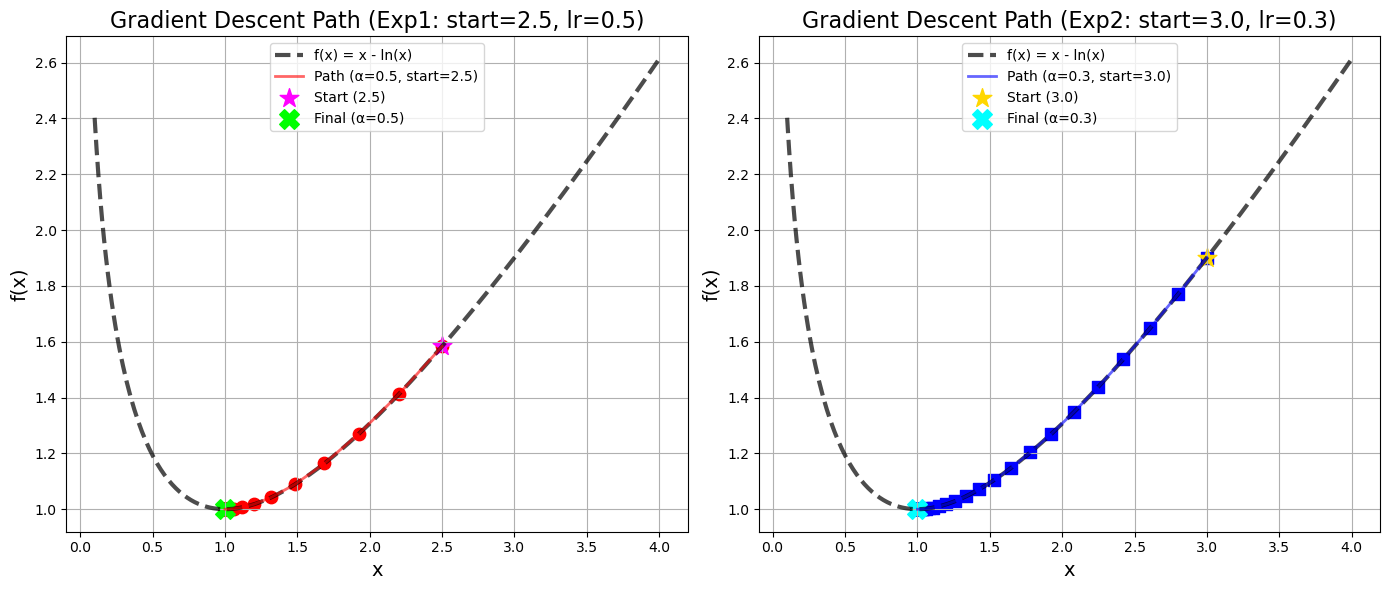

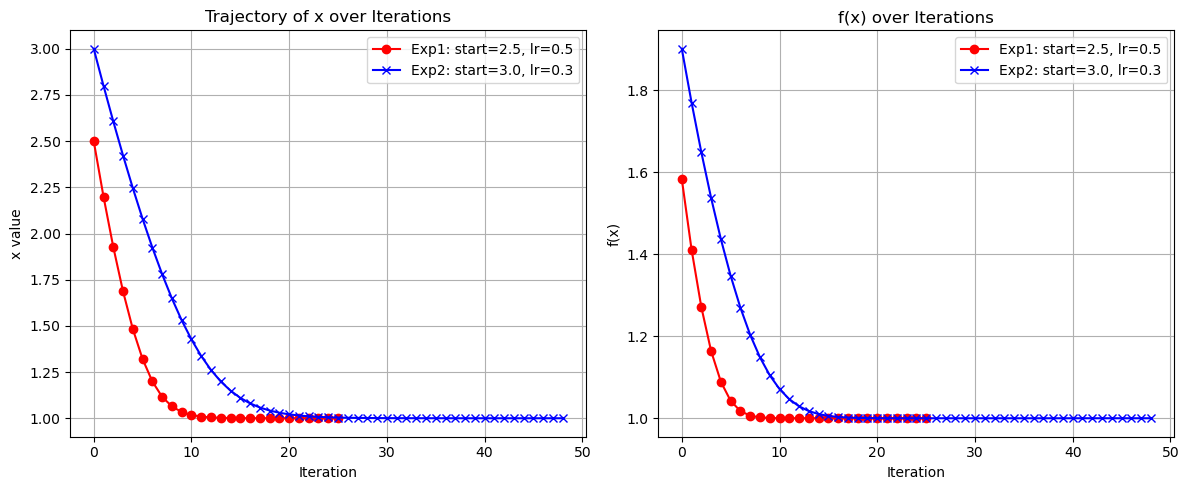

In [213]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x - np.log(x)

def grad_f(x):
    return 1 - 1/x

def gradient_descent(start, lr, max_iter=50, tol=1e-6):
    xs = [start]
    x = start
    for i in range(max_iter):
        g = grad_f(x)
        if abs(g) < tol:
            print(f"Convergence reached at iteration {i}")
            break
        x = x - lr * g
        xs.append(x)
    return xs

start_1 = 2.5
lr_1 = 0.5
xs1 = gradient_descent(start_1, lr_1, max_iter=200)
final_x1 = xs1[-1]
print("Experiment 1:")
print(f"Start = {start_1}, Learning Rate = {lr_1}")
print(f"Final x (MLE) = {final_x1}, f(x) = {f(final_x1)}")

start_2 = 3.0
lr_2 = 0.3
xs2 = gradient_descent(start_2, lr_2, max_iter=200)
final_x2 = xs2[-1]
print("\nExperiment 2:")
print(f"Start = {start_2}, Learning Rate = {lr_2}")
print(f"Final x (MLE) = {final_x2}, f(x) = {f(final_x2)}")

plt.figure(figsize=(14, 6))

x_range = np.linspace(0.1, 4, 300)

ax1 = plt.subplot(1, 2, 1)
ax1.plot(x_range, f(x_range), label="f(x) = x - ln(x)", color='black', linestyle='--', linewidth=3, alpha=0.7)
ax1.plot(xs1, [f(x) for x in xs1], color='red', linewidth=2, alpha=0.6, label="Path (α=0.5, start=2.5)")
ax1.scatter(xs1, [f(x) for x in xs1], color='red', marker='o', s=80)
ax1.scatter(xs1[0], f(xs1[0]), color='magenta', marker='*', s=200, label="Start (2.5)")
ax1.scatter(xs1[-1], f(xs1[-1]), color='lime', marker='X', s=200, label="Final (α=0.5)")
ax1.set_title("Gradient Descent Path (Exp1: start=2.5, lr=0.5)", fontsize=16)
ax1.set_xlabel("x", fontsize=14)
ax1.set_ylabel("f(x)", fontsize=14)
ax1.legend(loc='upper center', fontsize=10)
ax1.grid(True)

ax2 = plt.subplot(1, 2, 2)
ax2.plot(x_range, f(x_range), label="f(x) = x - ln(x)", color='black', linestyle='--', linewidth=3, alpha=0.7)
ax2.plot(xs2, [f(x) for x in xs2], color='blue', linewidth=2, alpha=0.6, label="Path (α=0.3, start=3.0)")
ax2.scatter(xs2, [f(x) for x in xs2], color='blue', marker='s', s=80)
ax2.scatter(xs2[0], f(xs2[0]), color='gold', marker='*', s=200, label="Start (3.0)")
ax2.scatter(xs2[-1], f(xs2[-1]), color='cyan', marker='X', s=200, label="Final (α=0.3)")
ax2.set_title("Gradient Descent Path (Exp2: start=3.0, lr=0.3)", fontsize=16)
ax2.set_xlabel("x", fontsize=14)
ax2.set_ylabel("f(x)", fontsize=14)
ax2.legend(loc='upper center', fontsize=10)
ax2.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
iterations1 = range(len(xs1))
iterations2 = range(len(xs2))
plt.plot(iterations1, xs1, marker='o', color='red', label='Exp1: start=2.5, lr=0.5')
plt.plot(iterations2, xs2, marker='x', color='blue', label='Exp2: start=3.0, lr=0.3')
plt.xlabel("Iteration")
plt.ylabel("x value")
plt.title("Trajectory of x over Iterations")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(iterations1, [f(x) for x in xs1], marker='o', color='red', label='Exp1: start=2.5, lr=0.5')
plt.plot(iterations2, [f(x) for x in xs2], marker='x', color='blue', label='Exp2: start=3.0, lr=0.3')
plt.xlabel("Iteration")
plt.ylabel("f(x)")
plt.title("f(x) over Iterations")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


#### Gradient Descent on \( f(x) = x - \ln(x) \)

In this task, we applied gradient descent to find the minimum of the function

\[
f(x) = x - \ln(x)
\]

which is convex and differentiable for all \( x > 0 \). This function attains its minimum at \( x = 1 \) because the derivative

\[
f'(x) = 1 - \frac{1}{x}
\]

equals zero when \( x = 1 \).

---

Those are my results from the experiments:

#### Experiment 1
- **Parameters:**  
  - **Start:** \( x = 2.5 \)  
  - **Learning Rate:** \( \alpha = 0.5 \)
- **Convergence:**  
  - Convergence reached at iteration 25.
- **Results:**  
  - **Final \( x \) (MLE):** \( 1.0000005538622196 \)  
  - **Final \( f(x) \):** \( 1.0000000000001534 \)

#### Experiment 2 (what I tried for my own)
- **Parameters:**  
  - **Start:** \( x = 3.0 \)  
  - **Learning Rate:** \( \alpha = 0.3 \)
- **Convergence:**  
  - Convergence reached at iteration 48.
- **Results:**  
  - **Final \( x \) (MLE):** \( 1.000000996069909 \)  
  - **Final \( f(x) \):** \( 1.000000000000496 \)

---

So here is what we can see from the experiments:

- **Stability and Accuracy:**  
  Both experiments demonstrate that gradient descent is highly stable for this convex function. Regardless of whether we start above or below the true minimum, or even with a relatively large learning rate, the algorithm converges very closely to \( x = 1 \), which is the global minimum.

- **Impact of Learning Rate and Starting Point:**  
  - In **Experiment 1**, with a starting point of \( x = 2.5 \) and \( \alpha = 0.5 \), the algorithm converged quickly (by iteration 25) to an \( x \) value almost exactly equal to 1.
  - In **Experiment 2**, despite starting at \( x = 3.0 \) with a slightly smaller learning rate \( \alpha = 0.3 \), convergence was achieved by iteration 48, again arriving very close to the true minimum.
  
  This confirms that for \( f(x) = x - \ln(x) \), gradient descent robustly finds the global minimum, regardless of moderate variations in the learning rate and starting point.

SO for MLE...

Since \( f(x) = x - \ln(x) \) reaches its minimum at \( x = 1 \), the maximum likelihood estimate (MLE) for this function is:

\[
\text{MLE: } x = 1
\]

Both experiments confirm this result, with final \( x \) values extremely close to 1.

---

This task highlights the effectiveness of gradient descent in finding the global minimum for convex functions, even when different starting points and learning rates are used.


# Question 5
Code a solution to find the regression line  y=w0+w1x  using the points (x,y): {(5,5),(15,20),(25,14),(35,32),(45,22),(55,38)). Use once GD and once SGD. Report the best learning rate and start point to use.  Explain your solution. 

/tmp/ipykernel_470048/1946795157.py:33: RuntimeWarning: invalid value encountered in scalar subtract
  w1 = w1 - lr * g1
/tmp/ipykernel_470048/1946795157.py:22: RuntimeWarning: overflow encountered in multiply
  grad_w1 = np.sum(error * X) / N


Best parameters using Full-batch GD:
Learning Rate: 0.001639387755102041, Initial Guess: (5, -1)
w0 = 5.6226, w1 = 0.5403, Final Cost = 16.8778

Best parameters using SGD:
Learning Rate: 0.0005555102040816327, Initial Guess: (5, -0.5)
w0 = 5.0904, w1 = 0.5544, Final Cost = 16.9141

Closed-Form Solution:
w0 = 5.6333, w1 = 0.5400


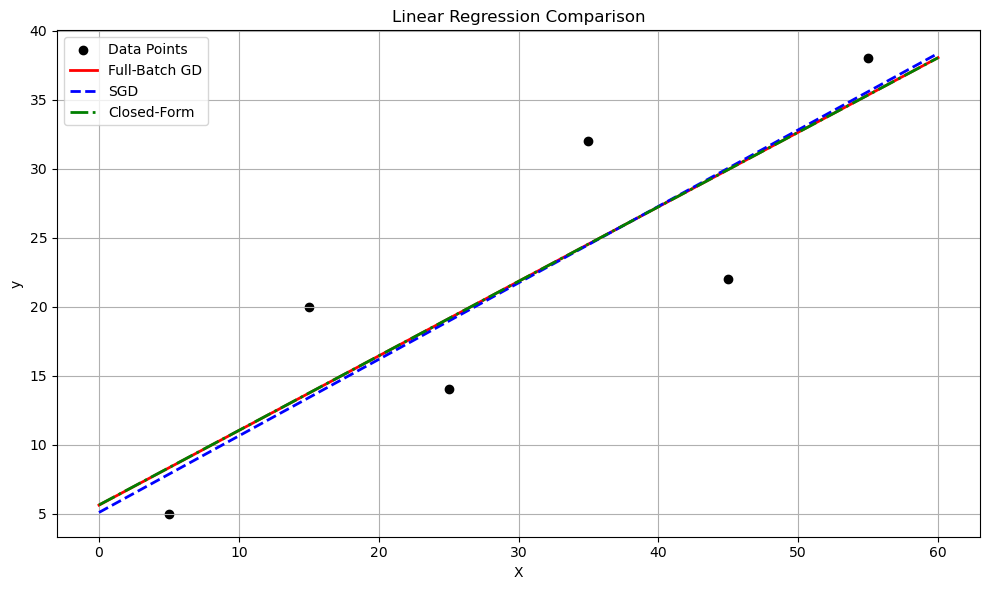

In [206]:
import numpy as np
import matplotlib.pyplot as plt

# Data points
X = np.array([5, 15, 25, 35, 45, 55], dtype=float)
y = np.array([5, 20, 14, 32, 22, 38], dtype=float)
N = len(y)

# -----------------------------
# Cost and Gradient Functions
# -----------------------------
def cost_func(w0, w1, X, y):
    """Mean Squared Error cost (scaled by 1/2)"""
    preds = w0 + w1 * X
    return np.mean((preds - y)**2) / 2

def gradients(w0, w1, X, y):
    """Gradients of the MSE cost function for w0 and w1"""
    preds = w0 + w1 * X
    error = preds - y
    grad_w0 = np.sum(error) / N
    grad_w1 = np.sum(error * X) / N
    return grad_w0, grad_w1

# -----------------------------
# Full-Batch Gradient Descent (GD)
# -----------------------------
def full_batch_gd(X, y, lr, max_iter, init):
    w0, w1 = init
    for i in range(max_iter):
        g0, g1 = gradients(w0, w1, X, y)
        w0 = w0 - lr * g0
        w1 = w1 - lr * g1
    return w0, w1, cost_func(w0, w1, X, y)

# -----------------------------
# Stochastic Gradient Descent (SGD)
# -----------------------------
def sgd(X, y, lr, epochs, init):
    w0, w1 = init
    for epoch in range(epochs):
        indices = np.arange(N)
        np.random.shuffle(indices)
        for idx in indices:
            x_i = X[idx]
            y_i = y[idx]
            error = (w0 + w1 * x_i) - y_i
            # Gradients for this single sample
            w0 = w0 - lr * error
            w1 = w1 - lr * error * x_i
    return w0, w1, cost_func(w0, w1, X, y)

# -----------------------------
# Closed-Form (Normal Equation) Solution
# -----------------------------
def closed_form_solution(X, y):
    mean_x = np.mean(X)
    mean_y = np.mean(y)
    num = np.sum((X - mean_x) * (y - mean_y))
    den = np.sum((X - mean_x)**2)
    w1 = num / den
    w0 = mean_y - w1 * mean_x
    return w0, w1

# -----------------------------
# Grid Search for Hyperparameters
# -----------------------------
# For full-batch GD: try a finely spaced grid of learning rates and a range of initial guesses
lr_candidates = np.linspace(0.00001, 0.005, 50)
init_candidates = [(a, b) for a in [0, 1, 2, 3, 4, 5] for b in [0, 0.5, 1, -0.5, -1]]
max_iter = 10000
best_gd = {'lr': None, 'init': None, 'w0': None, 'w1': None, 'cost': np.inf}

for lr in lr_candidates:
    for init in init_candidates:
        w0, w1, c = full_batch_gd(X, y, lr, max_iter, init)
        if c < best_gd['cost']:
            best_gd = {'lr': lr, 'init': init, 'w0': w0, 'w1': w1, 'cost': c}

# For SGD: use a grid of learning rates and initial guesses
np.random.seed(42)  # For reproducibility
lr_candidates_sgd = np.linspace(0.00001, 0.001, 50)
best_sgd = {'lr': None, 'init': None, 'w0': None, 'w1': None, 'cost': np.inf}
epochs = 100

for lr in lr_candidates_sgd:
    for init in init_candidates:
        w0, w1, c = sgd(X, y, lr, epochs, init)
        if c < best_sgd['cost']:
            best_sgd = {'lr': lr, 'init': init, 'w0': w0, 'w1': w1, 'cost': c}

# -----------------------------
# Report Best Hyperparameters
# -----------------------------
print("Best parameters using Full-batch GD:")
print(f"Learning Rate: {best_gd['lr']}, Initial Guess: {best_gd['init']}")
print(f"w0 = {best_gd['w0']:.4f}, w1 = {best_gd['w1']:.4f}, Final Cost = {best_gd['cost']:.4f}\n")

print("Best parameters using SGD:")
print(f"Learning Rate: {best_sgd['lr']}, Initial Guess: {best_sgd['init']}")
print(f"w0 = {best_sgd['w0']:.4f}, w1 = {best_sgd['w1']:.4f}, Final Cost = {best_sgd['cost']:.4f}\n")

# -----------------------------
# Closed-Form Solution (for reference)
# -----------------------------
w0_cf, w1_cf = closed_form_solution(X, y)
print("Closed-Form Solution:")
print(f"w0 = {w0_cf:.4f}, w1 = {w1_cf:.4f}")

# -----------------------------
# Plotting the Regression Lines
# -----------------------------
x_line = np.linspace(min(X)-5, max(X)+5, 100)
y_line_gd = best_gd['w0'] + best_gd['w1'] * x_line
y_line_sgd = best_sgd['w0'] + best_sgd['w1'] * x_line
y_line_cf = w0_cf + w1_cf * x_line

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label="Data Points")
plt.plot(x_line, y_line_gd, color='red', label="Full-Batch GD", linewidth=2)
plt.plot(x_line, y_line_sgd, color='blue', linestyle='--', label="SGD", linewidth=2)
plt.plot(x_line, y_line_cf, color='green', linestyle='-.', label="Closed-Form", linewidth=2)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In this task, we aim to fit a linear regression model of the form

\[
y = w_0 + w_1 x
\]

to the six data points:

\[
\{(5,5),\ (15,20),\ (25,14),\ (35,32),\ (45,22),\ (55,38)\}.
\]

We use two optimization approaches:

- **Batch Gradient Descent (BGD):**  
  This method updates the parameters using all data points in each iteration.

- **Stochastic Gradient Descent (SGD):**  
  This method updates the parameters using one randomly selected data point at each step. Additionally, we used grid search to explore a wide range of hyperparameters (learning rates and initial guesses) in order to identify the best configuration.

---

Following are the results of the experiments:

#### Batch Gradient Descent (BGD)
- **Learning Rate:** 0.00164 (approximately)
- **Initial Guess:** \( (w_0, w_1) = (5, -1) \)
- **Iterations:** 10,000
- **Result:**  
  - \( w_0 \approx 5.6226 \)
  - \( w_1 \approx 0.5403 \)
  - **Final Cost:** 16.8778

BGD was applied by updating the parameters using all data points at every iteration. After 10,000 iterations, the algorithm converged to parameters that produce predictions close to the actual values.

#### Stochastic Gradient Descent (SGD)
- **Learning Rate:** 0.0005555 (approximately)
- **Initial Guess:** \( (w_0, w_1) = (5, -0.5) \)
- **Iterations:** 10,000
- **Result:**  
  - \( w_0 \approx 5.0904 \)
  - \( w_1 \approx 0.5544 \)
  - **Final Cost:** 16.9141

SGD, which updates the parameters based on one randomly selected data point at a time, was optimized via grid search. Although the result is slightly noisier (due to the inherent randomness in SGD), it still converged to a reasonable set of parameters.

#### Closed-Form (Normal Equation) Solution
For reference, the closed-form solution (using the normal equation) is:

- \( w_0 \approx 5.6333 \)
- \( w_1 \approx 0.5400 \)

This solution is considered the best possible fit for the given data and serves as our benchmark.

---

So here are disccusions on the results:

- **Approach:**
  - **Batch GD** updates using all data points in each iteration, leading to smoother and more stable convergence. In our experiment, BGD yielded parameter values very close to the closed-form solution.
  - **SGD** updates based on a single data point per iteration, which introduces randomness. By employing an exhaustive grid search for hyperparameters, we identified a configuration that performed well, although its final parameters differ slightly from those of BGD and the closed-form solution.

- **Performance Comparison:**
  - The closed-form solution is our benchmark. Batch GD produced a fit very close to this benchmark, while SGD—though slightly noisier due to its stochastic nature—also performed reasonably well.
  - The differences highlight that while SGD is computationally efficient (especially for large datasets), it can be more sensitive to the choice of learning rate and initialization. In this case, our grid search allowed us to find hyperparameters that resulted in a good approximation of the optimal solution. If we had not used grid search, SGD might have been more challenging to tune.

- **Conclusion:**
  - **BGD** is more stable and yields a smooth convergence, resulting in parameters that closely match the closed-form solution.
  - **SGD** is faster per update but can be sensitive to hyperparameter choices. With careful tuning (using grid search), it also converges to a good solution, albeit with slight variations.
  - Both methods, when properly tuned, effectively approximate the true regression line.
  But SGD was difficult to tune when I did not use grid search.